In [1]:
%matplotlib widget 
# Uncomment for interactive plots when running the notebook!

import os.path

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import graspfile.grid as gfgrid
import graspfile.cut as gfcut

import PyPO.Colormaps as cmaps

from plotters import *

In [2]:
pypo_results = os.path.join('..', 'pypo', 'results', 'sma_cassegrain')
grasp_results = os.path.join('..', 'grasp', 'cassegrain', 'SMA_Cassegrain')

# Compare fields on secondary

In [3]:
# Load PyPO fields

EH_sec = np.load(os.path.join(pypo_results, 'EH_sec_fields.npz'))
JM_sec = np.load(os.path.join(pypo_results, 'JM_sec_currents.npz'))
grid_sec = np.load(os.path.join(pypo_results, 'EH_sec_fields_grid.npz'))

In [ ]:
# Load GRASP fields
GJM_sec = gfgrid.GraspGrid()
GJM_sec.read(open(os.path.join(grasp_results, "Job_12", "sma_cassegrain_seccur_gbfeed_po.grd")))
GEH_sec = gfgrid.GraspGrid()
GEH_sec.read(open(os.path.join(grasp_results, "Job_12", "sma_cassegrain_secE_gbfeed_po.grd")))

/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:79: RuntimeWarning: divide by zero encountered in log10
  ampplt = ax[0].pcolormesh(grid["x"], grid["y"], 20*np.log10(np.abs(field[comp])), cmap=amp_cmap, vmin=vmin, vmax=vmax)


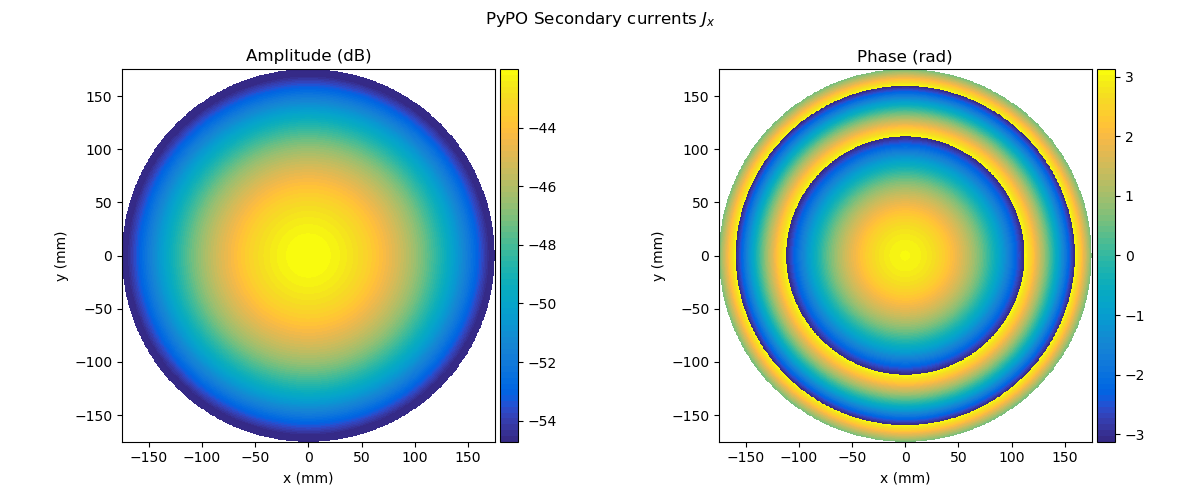

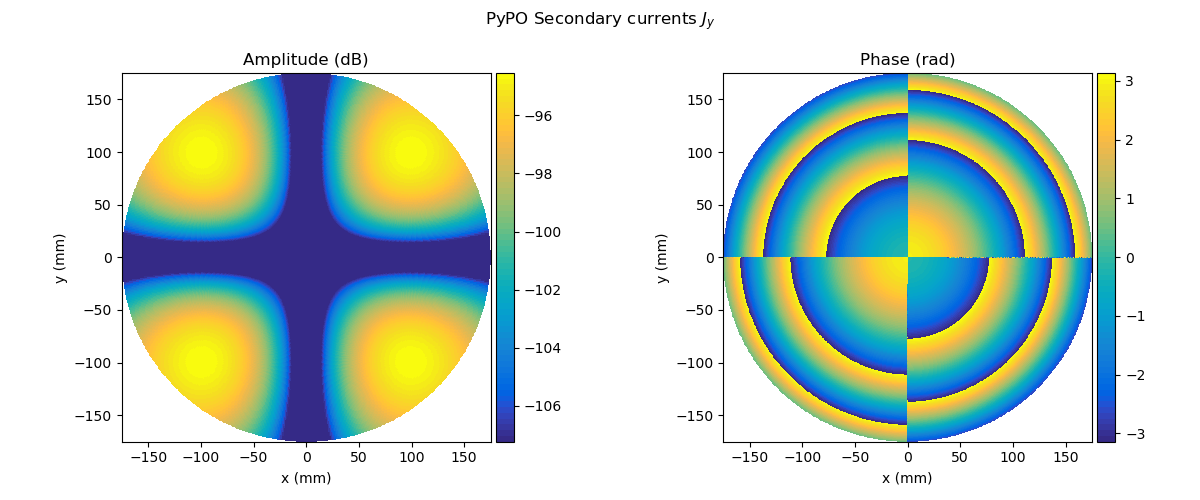

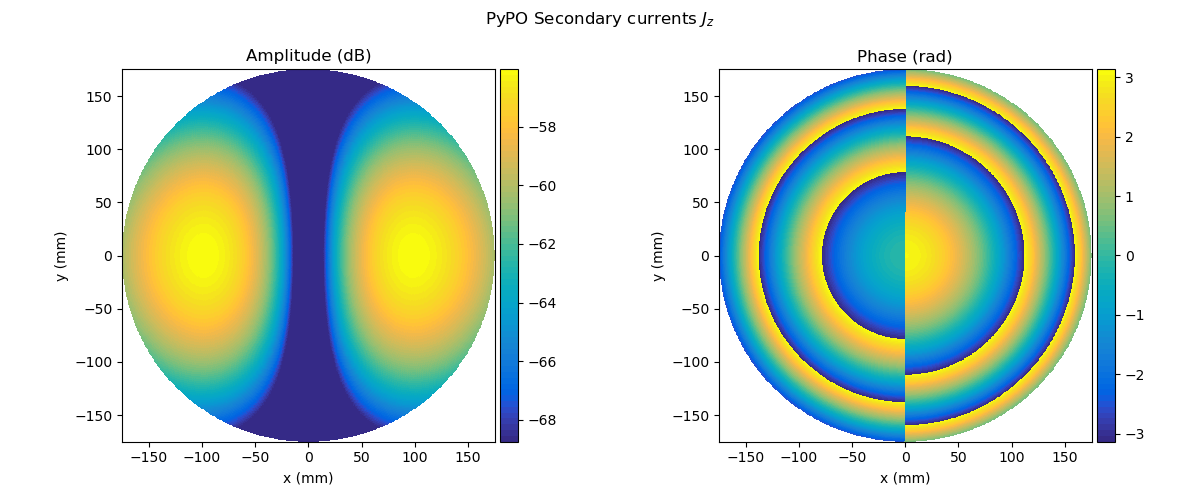

In [36]:
fig, ax = plotBeam2D(grid_sec, JM_sec, comp='Jx', correct_phase=1, title="PyPO Secondary currents", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_cur_po_PyPO_Jx.png')
fig, ax = plotBeam2D(grid_sec, JM_sec, comp='Jy', correct_phase=1, title="PyPO Secondary currents", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_cur_po_PyPO_Jy.png')
fig, ax = plotBeam2D(grid_sec, JM_sec, comp='Jz', correct_phase=1, title="PyPO Secondary currents", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_cur_po_PyPO_Jz.png')

/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:79: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ampplt = ax[0].pcolormesh(grid["x"], grid["y"], 20*np.log10(np.abs(field[comp])), cmap=amp_cmap, vmin=vmin, vmax=vmax)
/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:80: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  phsplt = ax[1].pcolormesh(grid["x"], grid["y"], np.angle(field[comp]*phase_factor), cmap=phs_cmap)


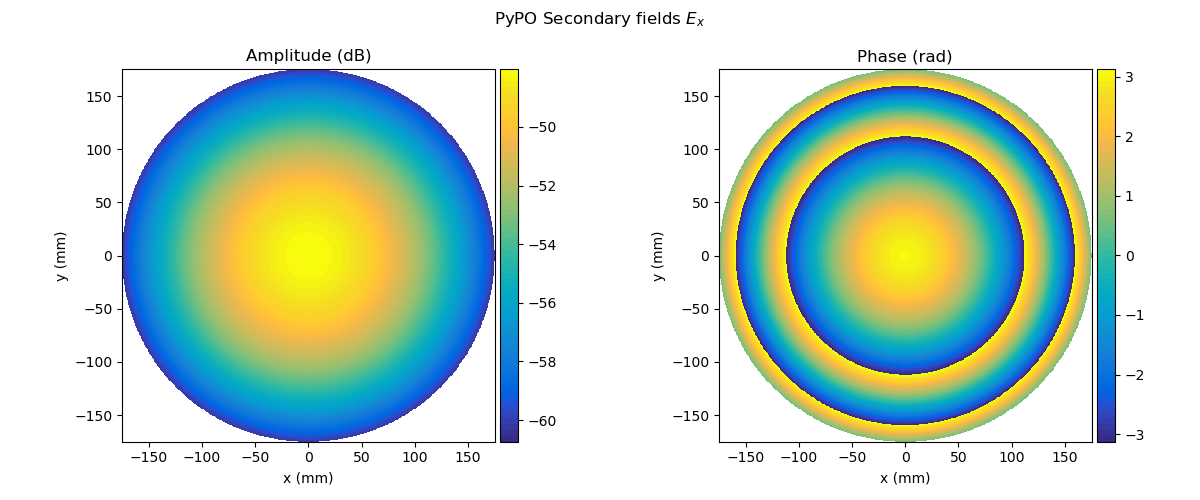

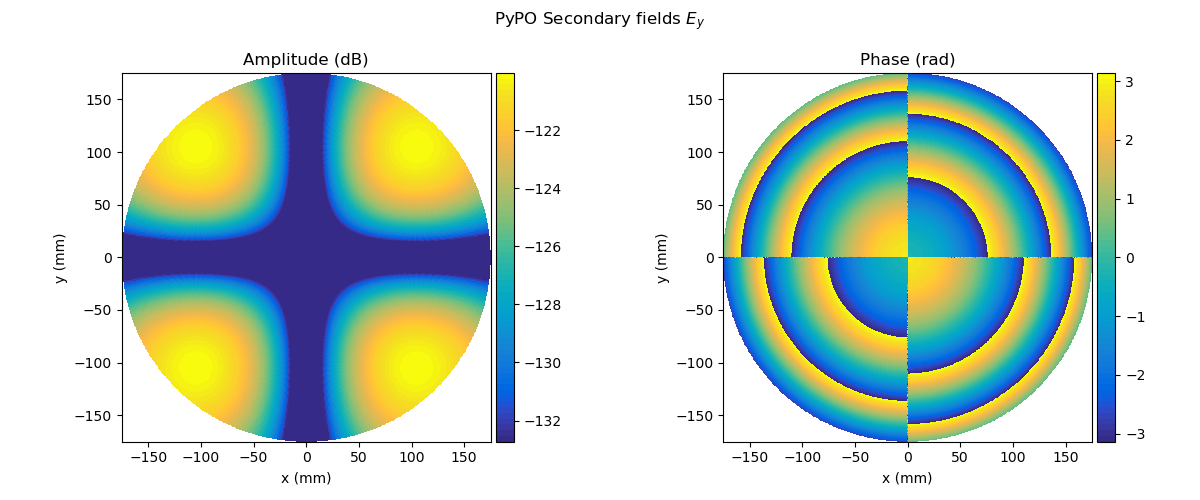

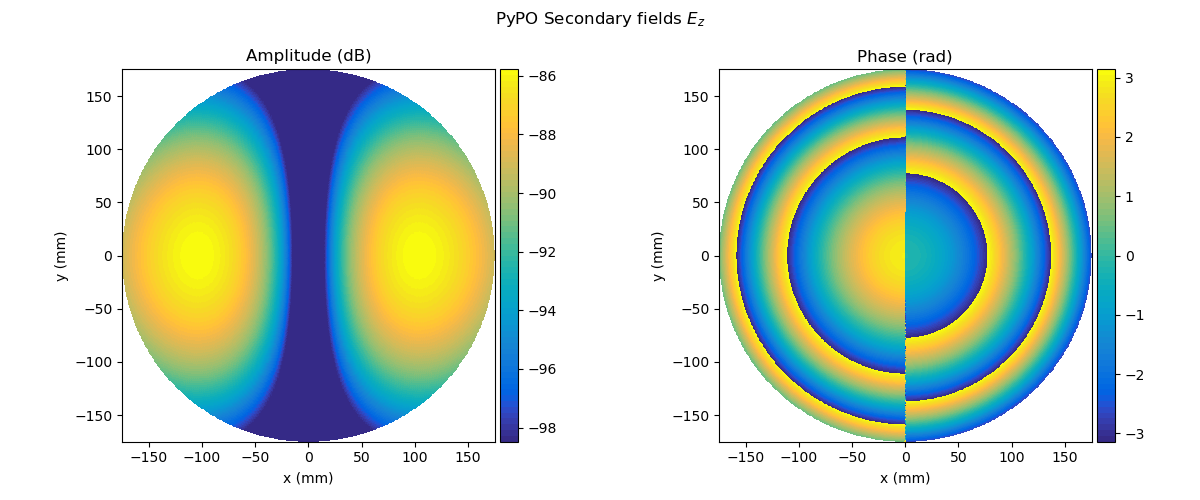

In [37]:
fig, ax = plotBeam2D(grid_sec, EH_sec, comp='Ex', correct_phase=1, title="PyPO Secondary fields", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_po_PyPO_Ex.png')
fig, ax = plotBeam2D(grid_sec, EH_sec, comp='Ey', correct_phase=1, title="PyPO Secondary fields", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_po_PyPO_Ey.png')
fig, ax = plotBeam2D(grid_sec, EH_sec, comp='Ez', correct_phase=1, title="PyPO Secondary fields", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_po_PyPO_Ez.png')

/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:30: RuntimeWarning: divide by zero encountered in log10
  ampplt = ax[0].pcolormesh(field.positions[0], field.positions[1], 20*np.log10(np.abs(field.field[:,:,comp])), cmap=amp_cmap, vmin=vmin, vmax=vmax)


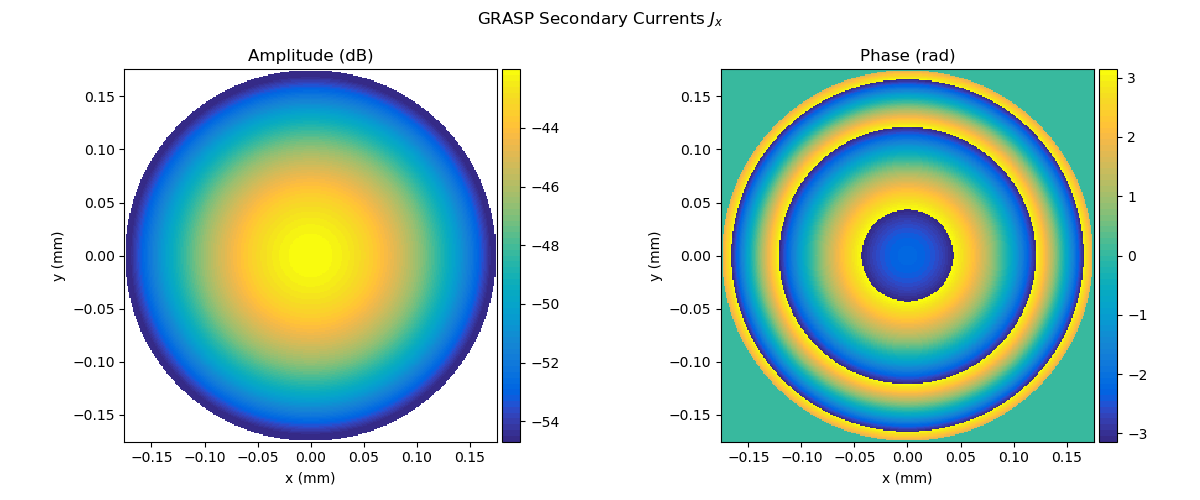

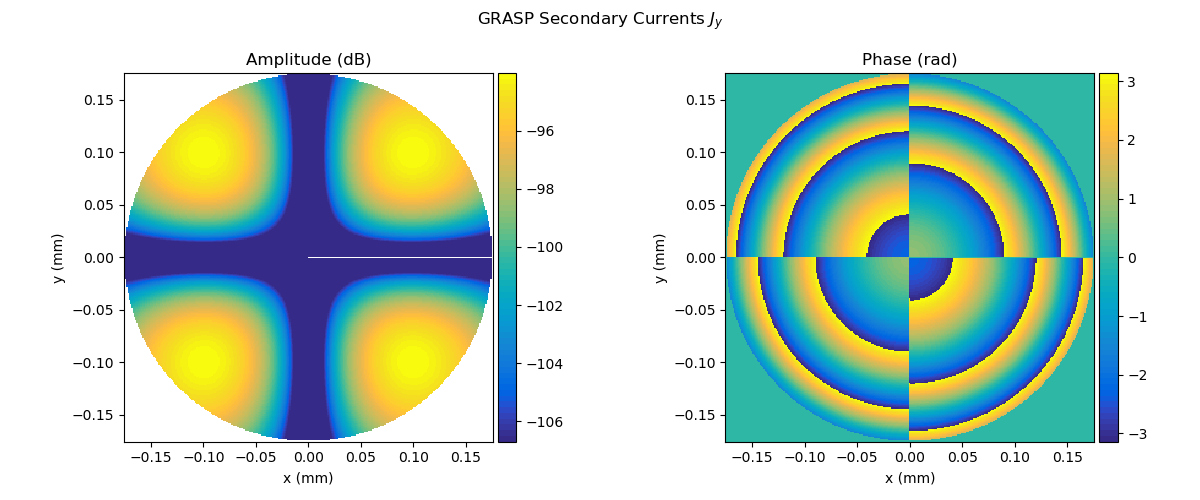

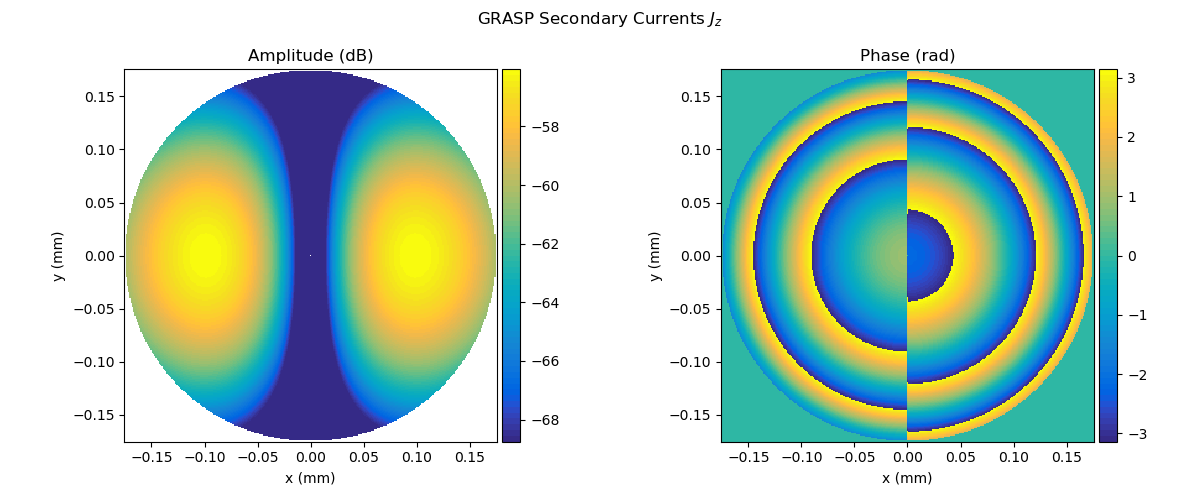

In [38]:
fig, ax = plotGraspBeam2D(GJM_sec.fields[0], comp=0, comp_name='J', title="GRASP Secondary Currents", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_cur_po_GRASP_Jx.png')
fig, ax = plotGraspBeam2D(GJM_sec.fields[0], comp=1, comp_name='J', title="GRASP Secondary Currents", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_cur_po_GRASP_Jy.png')
fig, ax = plotGraspBeam2D(GJM_sec.fields[0], comp=2, comp_name='J', title="GRASP Secondary Currents", vmin=-12.7)
fig.savefig('plots/cassegrain_sec_cur_po_GRASP_Jz.png')

/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:153: RuntimeWarning: divide by zero encountered in log10
  vmin = 20*np.log10(np.min(np.abs(y)))
/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:176: RuntimeWarning: divide by zero encountered in log10
  ampplt = ax[0].plot(x, 20*np.log10(np.abs(y)), label=label, **kwargs)
/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:248: RuntimeWarning: divide by zero encountered in log10
  vmin = 20*np.log10(np.min(np.abs(y)))
/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:262: RuntimeWarning: divide by zero encountered in log10
  ampplt = ax[0].plot(x*1e3, 20*np.log10(np.abs(y)), label=label, **kwargs)


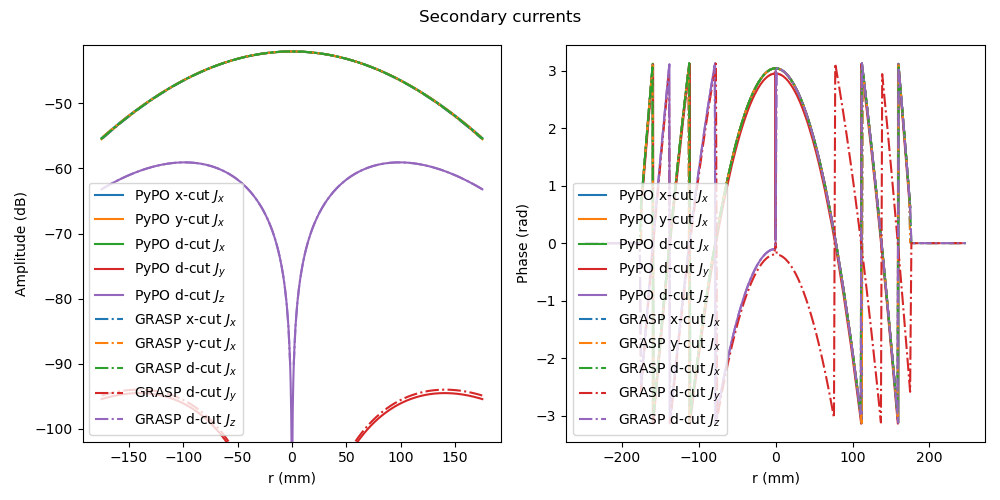

In [32]:
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='x', gmode='uv', comp='Jx', correct_phase=1, title="Secondary currents", label='PyPO x-cut', vmin=-60)
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='y', gmode='uv', comp='Jx', correct_phase=1, figax=(fig, ax), label='PyPO y-cut')
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='d', gmode='uv', comp='Jx', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='d', gmode='uv', comp='Jy', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='d', gmode='uv', comp='Jz', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
ax[0].set_prop_cycle(None)
ax[1].set_prop_cycle(None)
poffset = 2.117+np.pi
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='x', comp=0, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP x-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='y', comp=0, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP y-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='d', comp=0, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP d-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='d', comp=1, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP d-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='d', comp=2, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP d-cut', phase_offset=poffset)
ax[0].legend(loc='lower left')
ax[1].legend(loc='lower left')
fig.savefig("plots/cassegrain_sec_cur_po_cut")

In [ ]:
fig, ax = plotBeamCut(grid_sec, EH_sec, cut='x', gmode='uv', comp='Ex', correct_phase=1, title="Secondary fields", label='PyPO x-cut', vmin=-60)
fig, ax = plotBeamCut(grid_sec, EH_sec, cut='y', gmode='uv', comp='Ex', correct_phase=1, figax=(fig, ax), label='PyPO y-cut')
fig, ax = plotBeamCut(grid_sec, EH_sec, cut='d', gmode='uv', comp='Ex', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
fig, ax = plotBeamCut(grid_sec, EH_sec, cut='d', gmode='uv', comp='Ey', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
fig, ax = plotBeamCut(grid_sec, EH_sec, cut='d', gmode='uv', comp='Ez', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
ax[0].set_prop_cycle(None)
ax[1].set_prop_cycle(None)
poffset = 2.117+np.pi
fig, ax = plotGraspBeamCut(GEH_sec.fields[0], cut='x', comp=0, comp_name='E', figax=[fig, ax], ls='-.', label='GRASP x-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GEH_sec.fields[0], cut='y', comp=0, comp_name='E', figax=[fig, ax], ls='-.', label='GRASP y-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GEH_sec.fields[0], cut='d', comp=0, comp_name='E', figax=[fig, ax], ls='-.', label='GRASP d-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GEH_sec.fields[0], cut='d', comp=1, comp_name='E', figax=[fig, ax], ls='-.', label='GRASP d-cut', phase_offset=poffset)
fig, ax = plotGraspBeamCut(GEH_sec.fields[0], cut='d', comp=2, comp_name='E', figax=[fig, ax], ls='-.', label='GRASP d-cut', phase_offset=poffset)
ax[0].legend(loc='lower left')
ax[1].legend(loc='lower left')
fig.savefig("plots/cassegrain_sec_cur_po_cut")